# Кейс 6. Метрические методы регрессии

## 1. Импорты

In [1]:
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from sklearn.datasets import load_diabetes, fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from shared.metrics import mae, rmse, r2_score
from shared.validation import leave_one_out_regression
from case_6.src.regression import NadarayaWatson, LOWESS

import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs("plots", exist_ok=True)

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black"
})

## 2. Синтетические данные

In [3]:
np.random.seed(42)
x = np.linspace(0, 2 * np.pi, 150)
y_true = np.sin(x)
y = y_true + np.random.normal(0, 0.2, len(x))

x_train = x.reshape(-1, 1)

# Данные с выбросами для LOWESS
outlier_idx = np.random.choice(len(x), size=15, replace=False)
y_outliers = y.copy()
y_outliers[outlier_idx] += np.random.normal(0, 2.5, len(outlier_idx))

## 3. Влияние параметров и LOO-оптимизация

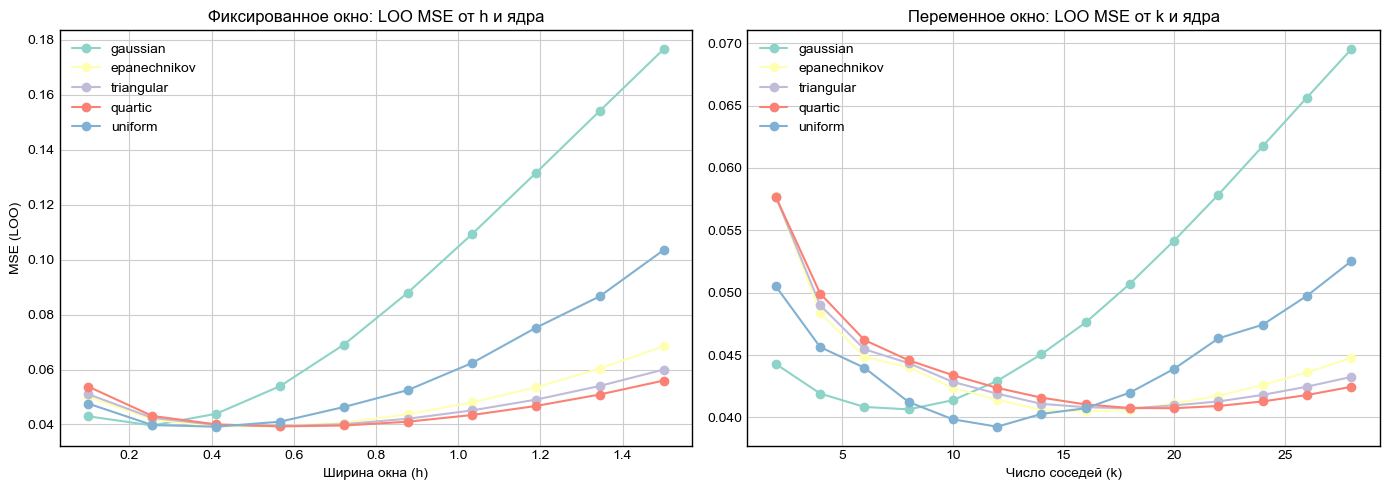

Метод,Оптимальное Ядро,Оптимальный параметр (h/k),LOO MSE
NW (Фиксированное окно),uniform,h = 0.41,0.0392
NW (Переменное окно),uniform,k = 12,0.0393


In [4]:
# Задаем сетки гиперпараметров
h_grid = np.linspace(0.1, 1.5, 10)
k_grid = range(2, 30, 2)
kernels_to_test = ['gaussian', 'epanechnikov', 'triangular', 'quartic', 'uniform']

results_fixed = []
results_var = []

# Перебор параметров по сетке
for kern in kernels_to_test:
    # Для фиксированного окна
    for h_val in h_grid:
        err = leave_one_out_regression(NadarayaWatson, {'h': h_val, 'kernel': kern}, x_train, y)
        results_fixed.append({'h': h_val, 'kernel': kern, 'err': err})

    # Для переменного окна
    for k_val in k_grid:
        err = leave_one_out_regression(NadarayaWatson, {'k': k_val, 'kernel': kern}, x_train, y)
        results_var.append({'k': k_val, 'kernel': kern, 'err': err})

df_fixed = pd.DataFrame(results_fixed)
df_var = pd.DataFrame(results_var)

# Совмещенные графики
plt.figure(figsize=(14, 5))

# График 1: Фиксированное окно
plt.subplot(1, 2, 1)
for kern in kernels_to_test:
    subset = df_fixed[df_fixed['kernel'] == kern]
    plt.plot(subset['h'], subset['err'], marker='o', label=kern)
plt.title("Фиксированное окно: LOO MSE от h и ядра")
plt.xlabel("Ширина окна (h)")
plt.ylabel("MSE (LOO)")
plt.legend()
plt.grid(True)

# График 2: Переменное окно
plt.subplot(1, 2, 2)
for kern in kernels_to_test:
    subset = df_var[df_var['kernel'] == kern]
    plt.plot(subset['k'], subset['err'], marker='o', label=kern)
plt.title("Переменное окно: LOO MSE от k и ядра")
plt.xlabel("Число соседей (k)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("plots/01_loo_parameters_grid.png.png", dpi=100, bbox_inches='tight')
plt.show()

# Извлечение лучших параметров
best_fixed_row = df_fixed.loc[df_fixed['err'].idxmin()]
best_var_row = df_var.loc[df_var['err'].idxmin()]

best_h = best_fixed_row['h']
best_kernel_h = best_fixed_row['kernel']

best_k = int(best_var_row['k'])
best_kernel_k = best_var_row['kernel']

best_params_df = pd.DataFrame({
    "Метод": ["NW (Фиксированное окно)", "NW (Переменное окно)"],
    "Оптимальное Ядро": [best_kernel_h, best_kernel_k],
    "Оптимальный параметр (h/k)": [f"h = {best_h:.2f}", f"k = {best_k}"],
    "LOO MSE": [best_fixed_row['err'], best_var_row['err']]
})

display(HTML("<h3>Оптимальные гиперпараметры регрессии</h3>"))
display(best_params_df.style.format({"LOO MSE": "{:.4f}"}).hide(axis="index"))

## 4. Визуализация прогноза

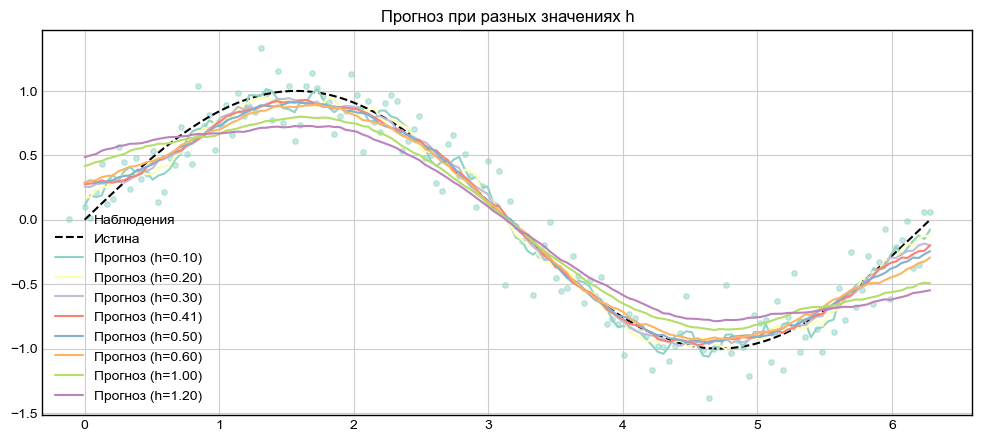

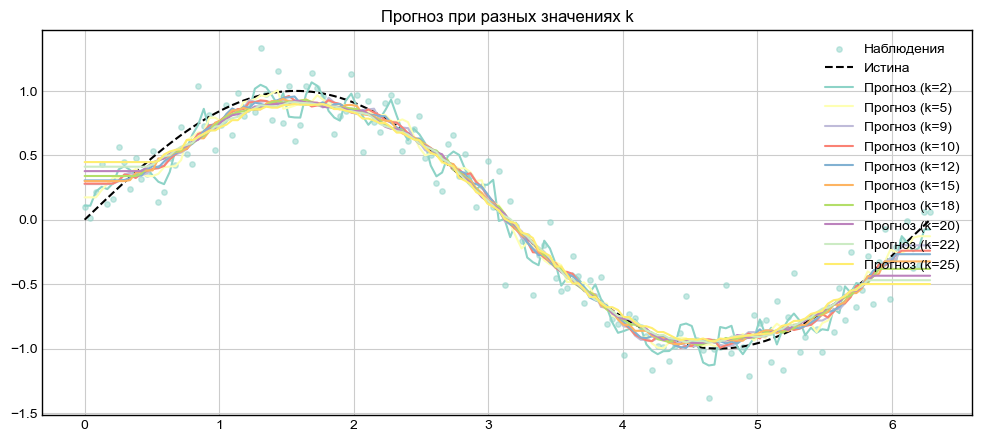

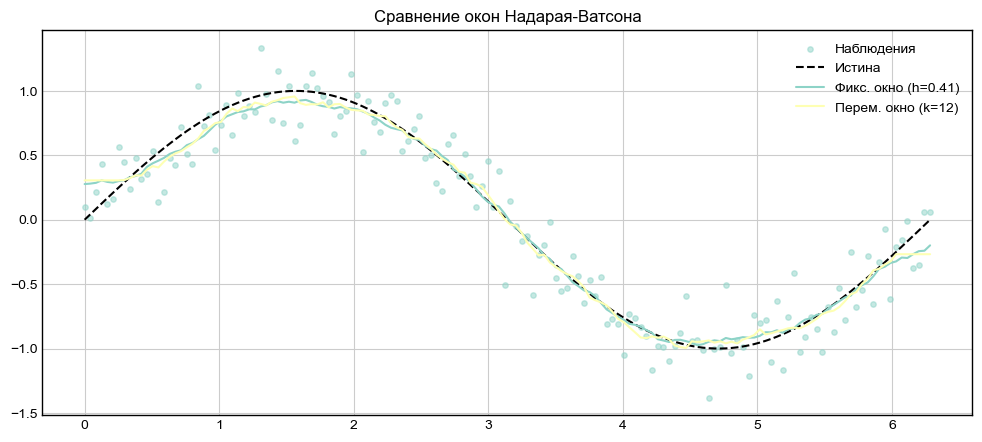

In [5]:
h_test_values = [0.1, 0.2, 0.3, best_h, 0.5, 0.6, 1.0, 1.2]

plt.figure(figsize=(12, 5))
plt.scatter(x, y, s=15, alpha=0.5, label="Наблюдения")
plt.plot(x, y_true, 'k--', label="Истина")

for h_val in h_test_values:
    nw_temp = NadarayaWatson(h=h_val, kernel=best_kernel_h).fit(x_train, y)
    plt.plot(x, nw_temp.predict(x_train), label=f"Прогноз (h={h_val:.2f})")

plt.legend()
plt.title("Прогноз при разных значениях h")
plt.savefig("plots/02_nw_different_h_forecasts.png", dpi=100, bbox_inches='tight')
plt.show()

k_test_values = [2, 5, 9, 10, best_k, 15, 18, 20, 22, 25]

plt.figure(figsize=(12, 5))
plt.scatter(x, y, s=15, alpha=0.5, label="Наблюдения")
plt.plot(x, y_true, 'k--', label="Истина")

for k_val in k_test_values:
    nw_temp = NadarayaWatson(k=k_val, kernel=best_kernel_k).fit(x_train, y)
    plt.plot(x, nw_temp.predict(x_train), label=f"Прогноз (k={k_val})")

plt.legend()
plt.title("Прогноз при разных значениях k")
plt.savefig("plots/03_nw_different_k_forecasts.png", dpi=100, bbox_inches='tight')
plt.show()

nw_fixed = NadarayaWatson(h=best_h, kernel=best_kernel_h).fit(x_train, y)
nw_var = NadarayaWatson(k=best_k, kernel=best_kernel_k).fit(x_train, y)

plt.figure(figsize=(12, 5))
plt.scatter(x, y, s=15, alpha=0.5, label="Наблюдения")
plt.plot(x, y_true, 'k--', label="Истина")
plt.plot(x, nw_fixed.predict(x_train), label=f"Фикс. окно (h={best_h:.2f})")
plt.plot(x, nw_var.predict(x_train), label=f"Перем. окно (k={best_k})")
plt.legend()
plt.title("Сравнение окон Надарая-Ватсона")
plt.savefig("plots/04_nw_windows_comparison.png", dpi=100, bbox_inches='tight')
plt.show()

## 5. LOWESS и устойчивость к выбросам

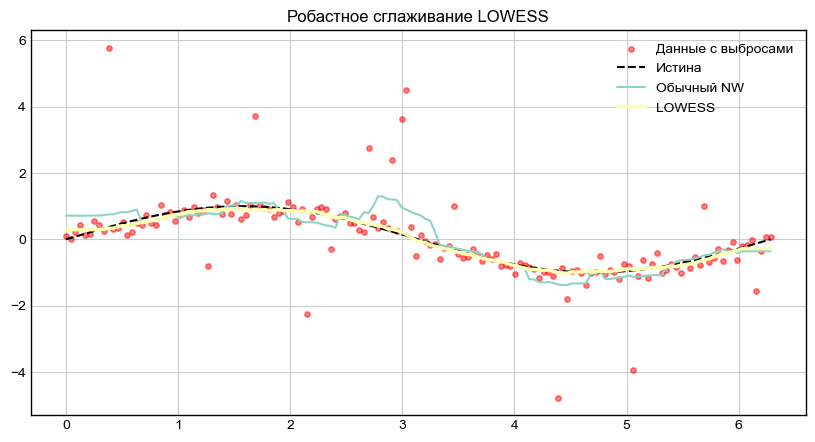

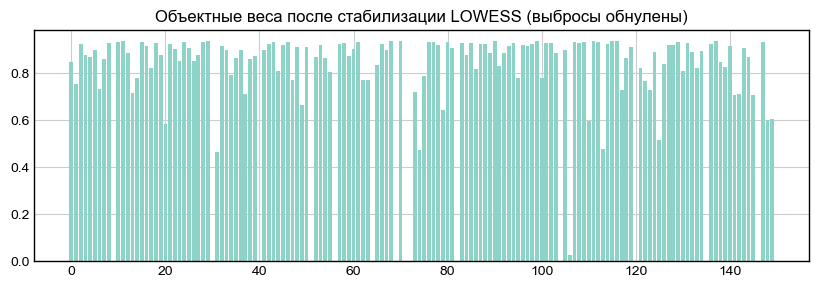

In [6]:
lowess = LOWESS(k=best_k, kernel=best_kernel_k, n_iter=5).fit(x_train, y_outliers)
nw_standard = NadarayaWatson(k=best_k, kernel=best_kernel_k).fit(x_train, y_outliers)

plt.figure(figsize=(10, 5))
plt.scatter(x, y_outliers, s=15, c='red', alpha=0.5, label="Данные с выбросами")
plt.plot(x, y_true, 'k--', label="Истина")
plt.plot(x, nw_standard.predict(x_train), label="Обычный NW")
plt.plot(x, lowess.predict(x_train), label="LOWESS", linewidth=2.5)
plt.legend()
plt.title("Робастное сглаживание LOWESS")
plt.savefig("plots/05_lowess_robust_smoothing.png", dpi=100, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 3))
plt.bar(range(len(lowess.robust_weights)), lowess.robust_weights)
plt.title("Объектные веса после стабилизации LOWESS (выбросы обнулены)")
plt.savefig("plots/06_lowess_robustness_weights.png", dpi=100, bbox_inches='tight')
plt.show()

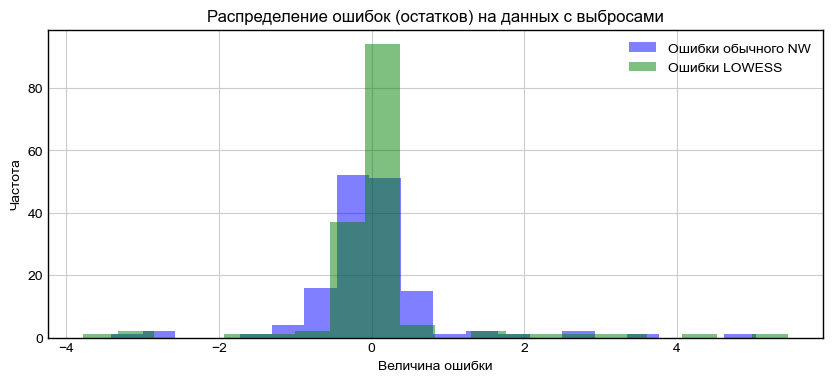

In [7]:
# Распределение остатков (ошибок) обычного NW и LOWESS
err_nw = y_outliers - nw_standard.predict(x_train)
err_lowess = y_outliers - lowess.predict(x_train)

plt.figure(figsize=(10, 4))
plt.hist(err_nw, bins=20, alpha=0.5, label="Ошибки обычного NW", color='blue')
plt.hist(err_lowess, bins=20, alpha=0.5, label="Ошибки LOWESS", color='green')
plt.title("Распределение ошибок (остатков) на данных с выбросами")
plt.xlabel("Величина ошибки")
plt.ylabel("Частота")
plt.legend()
plt.savefig("plots/07_error_residuals_distribution.png", dpi=100, bbox_inches='tight')
plt.show()

## 6. Реальные данные

In [8]:
# Загрузка и подготовка первого реального датасета: Diabetes
diabetes = load_diabetes()
X_db, y_db = diabetes.data, diabetes.target
X_db_scaled = StandardScaler().fit_transform(X_db)
X_tr_db, X_te_db, y_tr_db, y_te_db = train_test_split(X_db_scaled, y_db, test_size=0.2, random_state=42)

model_db = NadarayaWatson(k=10, kernel='epanechnikov').fit(X_tr_db, y_tr_db)
preds_db = model_db.predict(X_te_db)

# Загрузка и подготовка второго реального датасета: California Housing
housing = fetch_california_housing()
X_hs, y_hs = housing.data, housing.target
X_hs_scaled = StandardScaler().fit_transform(X_hs)
X_tr_hs, X_te_hs, y_tr_hs, y_te_hs = train_test_split(X_hs_scaled, y_hs, test_size=0.2, random_state=42)

model_hs = NadarayaWatson(k=15, kernel='epanechnikov').fit(X_tr_hs, y_tr_hs)
preds_hs = model_hs.predict(X_te_hs)

# Сводная таблица результатов
metrics_df = pd.DataFrame({
    "Метрика": ["MAE", "RMSE", "R^2"],
    "Diabetes": [mae(y_te_db, preds_db), rmse(y_te_db, preds_db), r2_score(y_te_db, preds_db)],
    "California Housing (subset)": [mae(y_te_hs, preds_hs), rmse(y_te_hs, preds_hs), r2_score(y_te_hs, preds_hs)]
})

display(HTML("<h3>Метрики на реальных датасетах (Nadaraya-Watson)</h3>"))
display(metrics_df.style.format({
    "Diabetes": "{:.4f}",
    "California Housing (subset)": "{:.4f}"
}).hide(axis="index"))

Метрика,Diabetes,California Housing (subset)
MAE,41.8141,0.4304
RMSE,54.0419,0.6378
R^2,0.4488,0.6895
